In [ ]:
import skimage
import numpy as np
import matplotlib.pyplot as plt

# Image Basic Operation

In [ ]:
from google.colab import files
f = files.upload()

Saving rgb_hsi.jpg to rgb_hsi.jpg


In [ ]:
img = skimage.io.imread('rgb_hsi.jpg')

In [ ]:
img.shape

(4901, 6126, 3)

In [ ]:
img

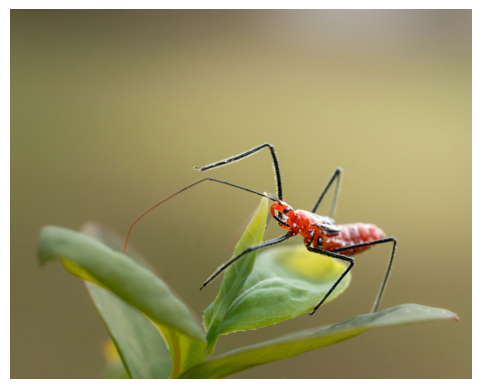

In [ ]:
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()

In [ ]:
red = img[:,:,0]

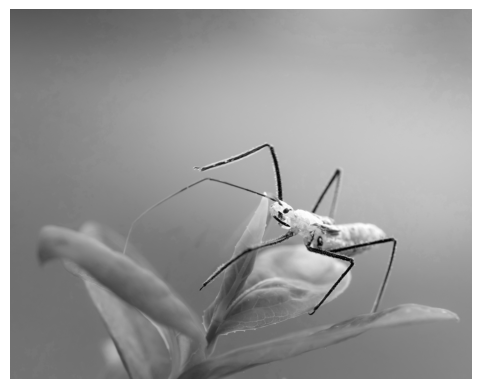

In [ ]:
plt.imshow(red, cmap='gray')
plt.axis('off')
plt.show()

In [ ]:
green = img[:,:,1]

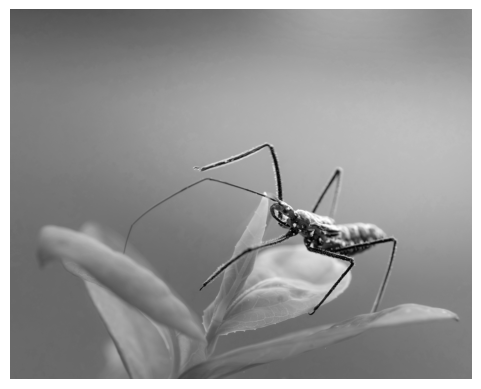

In [ ]:
plt.imshow(green, cmap='gray')
plt.axis('off')
plt.show()

In [ ]:
blue = img[:,:,2]

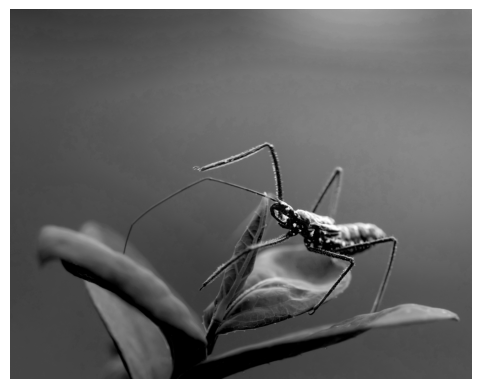

In [ ]:
plt.imshow(blue, cmap='gray')
plt.axis('off')
plt.show()

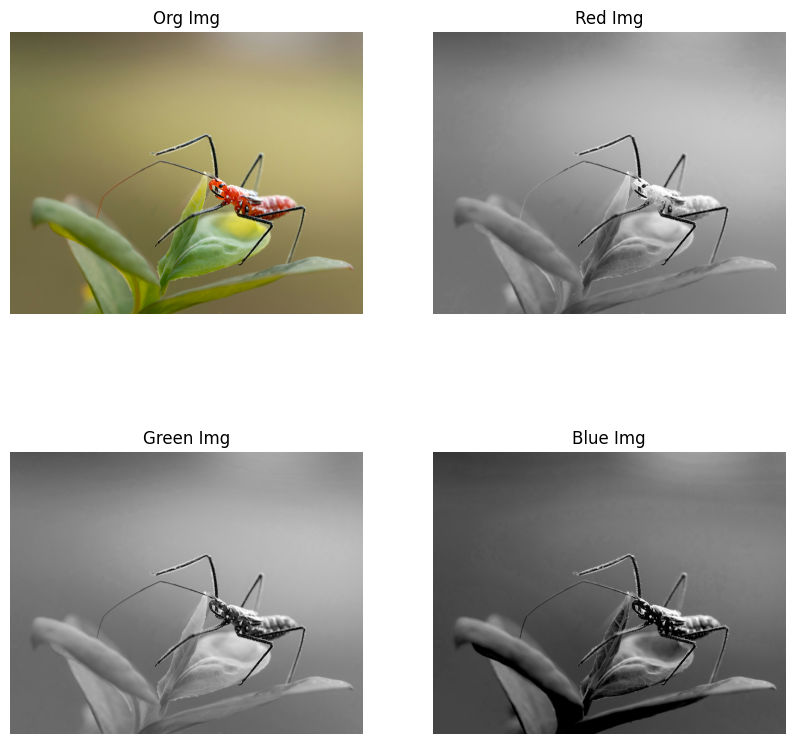

In [ ]:
plt.figure(figsize=(10, 10))
plt.subplot(2,2,1)
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.title("Org Img")
plt.subplot(2,2,2)
plt.imshow(red, cmap='gray')
plt.axis('off')
plt.title("Red Img")
plt.subplot(2,2,3)
plt.imshow(green, cmap='gray')
plt.axis('off')
plt.title("Green Img")
plt.subplot(2,2,4)
plt.imshow(blue, cmap='gray')
plt.axis('off')
plt.title("Blue Img")
plt.show()

In [ ]:
height = img.shape[0]
width = img.shape[1]
channels = img.shape[2]

print(f"Image Height: {height}, Width: {width},and color channel: {channels}")

# Flip Image

In [ ]:
# task for you
# Horizontal Flip and Vertial Flip

# Color Model

### CMY model

In [ ]:
# color model
# CMY color
red_img = img[:,:,0] # red color image
green_img = img[:,:,1] # green color image
blue_img = img[:,:,2] # blue color image

# convert from RGB to CMY
cyne = 255 - red_img
megenta = 255 - green_img
yellow = 255 - blue_img

cmy_img = np.stack((cyne, megenta, yellow), axis=-1)

plt.imshow(cmy_img, cmap='gray')
plt.show()

In [ ]:
plt.figure(figsize=(10, 10))
plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title('RGB Image')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(cmy_img, cmap='gray')
plt.title('CMY Image')
plt.axis('off')

plt.show()

### HSI Model

In [ ]:
# normlized image
img_norm = img.astype(np.float32)/255.0 # [0-1]range

# extract r,g,b
r = img_norm[:,:,0]
g = img_norm[:,:,1]
b = img_norm[:,:,2]

#------------------ (intensity) ----------------
I = (r+g+b)/3.0 # gray scale image (H,W,1)

# ------------------ (saturation) ---------------

min_rgb = np.minimum(np.minimum(r,g),b)
sum_rgb = r+g+b

S = np.zeros_like(I) # (array(0,0))
non_zero_pixel = sum_rgb>0
S[non_zero_pixel] = 1 - (3*min_rgb[non_zero_pixel])/sum_rgb[non_zero_pixel]

# ----------------- (Hue) ------------------
N = 0.5*((r-g)+(r-b))
D = np.sqrt((r-g)**2 + (r-b)*(g-b))
# avoid divide-by-zero
D = np.clip(D, 1e-6, None)
# theta calculation
theta = np.arccos(np.clip(N/D, -1, 1))

#
H = np.zeros_like(I)
H[b<=g] = theta[b<=g]
H[b>g] = 360 - theta[b>g]

H = H * (180/np.pi)
H = H / 360

HSI = np.stack((H,S,I), axis=-1)

NameError: name 'img' is not defined

In [ ]:
np.arccos(1)

np.float64(0.0)

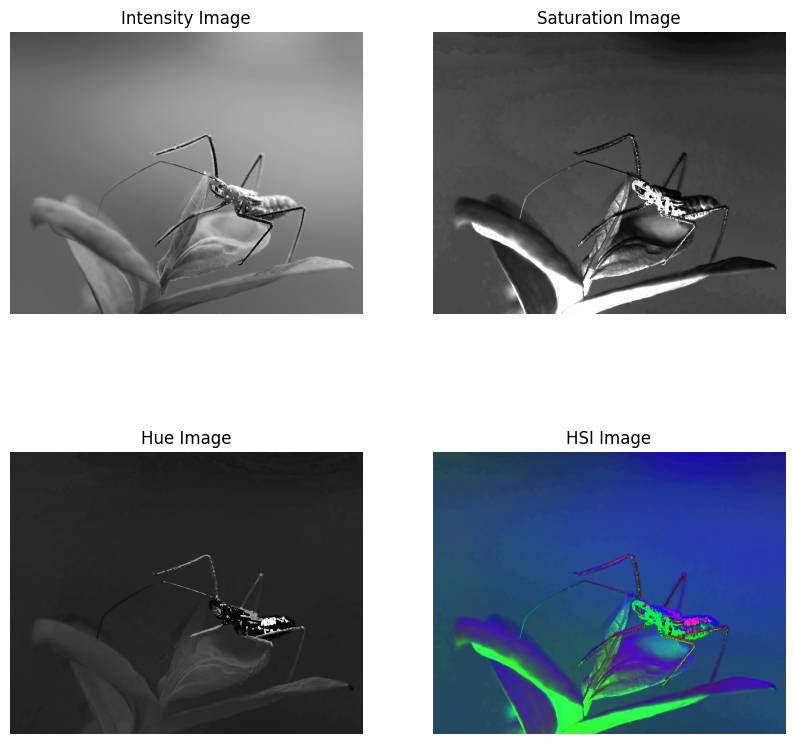

In [ ]:
plt.figure(figsize=(10, 10))
plt.subplot(2,2,1)
plt.imshow(I, cmap='gray')
plt.title('Intensity Image')
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(S, cmap='gray')
plt.title('Saturation Image')
plt.axis('off')

plt.subplot(2,2,3)
plt.imshow(H, cmap='gray')
plt.title('Hue Image')
plt.axis('off')

plt.subplot(2,2,4)
plt.imshow(HSI, cmap='gray')
plt.title('HSI Image')
plt.axis('off')
plt.show()